# **COVID-19 has created an urgent need for fast and reliable diagnostic tools. While RT-PCR tests are standard, they can be slow and limited in availability. Chest X-ray imaging offers a quicker, widely accessible alternative. This project focuses on using deep learning techniques, particularly convolutional neural networks (CNNs), to detect COVID-19 from chest X-ray images. The goal is to build an efficient, automated system to support early diagnosis and aid healthcare professionals in managing the pandemic more effectively.**



In [22]:
import torch
import numpy as np
import torch.nn as nn #neural networks
import torch.optim as optim # optimizer
from torch.utils.data import DataLoader


import torchvision
import torchvision.datasets as datasets # divide images to batches
import torchvision.transforms as transforms # work image augementation
import torchvision.datasets as ImageFolder

from torchvision.utils import make_grid
import matplotlib.pyplot as plt # show images


# we ahve two data training and testing data  so split the testing data

from torch.utils.data import random_split  # random spliting


In [23]:
data_path_train="/content/drive/MyDrive/Colab Notebooks/train"
data_path_test="/content/drive/MyDrive/Colab Notebooks/test"

In [24]:

img_size = 120

img_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),               # Resize image to 120x120
    transforms.RandomHorizontalFlip(),                     # Randomly flip image horizontally (data augmentation)
    transforms.ToTensor(),                                 # Convert image to PyTorch tensor (scales pixels to [0, 1])
    transforms.Normalize(mean=[0.485, 0.456, 0.475],        # Normalize using mean and std per channel
                         std=[0.229, 0.224, 0.225])         # Formula: (x - mean) / std
])


In [25]:
from torchvision.datasets import ImageFolder

train_data = ImageFolder(root=data_path_train, transform=img_transform)
test_data = ImageFolder(root=data_path_test, transform=img_transform)


In [26]:
len(train_data),len(test_data)

(256, 66)

In [27]:
train_data.class_to_idx

{'Covid': 0, 'Normal': 1, 'Viral Pneumonia': 2}

In [28]:
val_data, test_data = random_split(test_data,[50,16])

In [29]:
len(val_data), len(test_data)

(50, 16)

In [30]:
train_loader=DataLoader(train_data,batch_size=16,shuffle=True)
val_loader=DataLoader(val_data,batch_size=16,shuffle=True)

In [31]:
for image, label in train_loader:  #[N->batch size, c-> channel , height, widhth  ]
  print(image.shape)
  break

torch.Size([16, 3, 120, 120])


In [32]:
def show_img(data):
  for img, label in data:
    plt.figure(figsize=(12,4))
    plt.imshow(make_grid(img,nrow=4).permute(1,2,0))
    plt.show()
    break


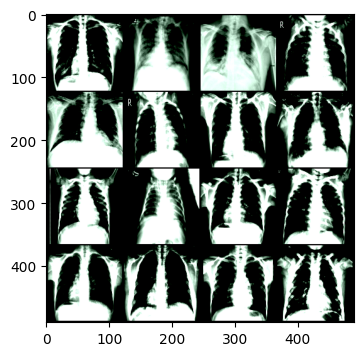

In [33]:
show_img(train_loader)

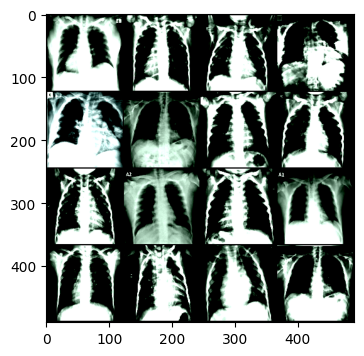

In [34]:
show_img(val_loader)

In [44]:
# nn.Module is parent class ANN child class
class ANN(nn.Module):
  def __init__(self,hidden_layer=64):
    super(ANN,self).__init__()

    self.fc1=nn.Linear(120*120*3,hidden_layer)
    self.fc2=nn.Linear(hidden_layer,3)  # 3 is the type of data we have
    self.relu= nn.ReLU()

  def forward(self,img):
    #[N C H W]
    out=img.view(-1,120*120*3)  # flatten the image change 2D to 1D
    out=self.fc1(out)
    out=self.relu(out)
    out=self.fc2(out)

    return out


In [45]:
model=ANN()

In [46]:
print(model)

ANN(
  (fc1): Linear(in_features=43200, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=3, bias=True)
  (relu): ReLU()
)


In [47]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layer = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 120x120 -> 60x60

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 60x60 -> 30x30

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 30x30 -> 15x15
        )

        self.fc_layer = nn.Sequential(
            nn.Flatten(),                      # 64*15*15 = 14400
            nn.Linear(64 * 15 * 15, 128),
            nn.ReLU(),
            nn.Linear(128, 3)                  # 3 output classes
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.fc_layer(x)
        return x


In [48]:
model=CNN()

In [49]:
print(model)

CNN(
  (conv_layer): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=14400, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [50]:
loss_fn=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=0.001)

In [53]:
import torch
import matplotlib.pyplot as plt

def train(model, loss_fn, optimizer, train_loader, val_loader, train_data, val_data, epochs=15):
    training_acc = []
    training_loss = []
    validation_acc = []
    validation_loss = []

    for epoch in range(epochs):
        train_loss = 0.0
        train_acc = 0.0
        model.train()  # Set model to training mode

        for images, labels in train_loader:
            optimizer.zero_grad()  # Reset gradients
            output = model(images)
            loss = loss_fn(output, labels)
            loss.backward()        # Backpropagation
            optimizer.step()       # Update weights

            prediction = torch.argmax(output, 1)
            train_acc += torch.sum(prediction == labels).item()
            train_loss += loss.item()

        training_loss.append(train_loss / len(train_loader))
        training_acc.append(train_acc / len(train_data))

        # Validation
        model.eval()
        val_loss = 0.0
        val_acc = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                output = model(images)
                loss = loss_fn(output, labels)

                prediction = torch.argmax(output, 1)
                val_acc += torch.sum(prediction == labels).item()
                val_loss += loss.item()

        validation_acc.append(val_acc / len(val_data))
        validation_loss.append(val_loss / len(val_loader))

        print(f"Epoch {epoch+1}, Training Acc: {training_acc[-1]:.2f}, Validation Acc: {validation_acc[-1]:.2f}, "
              f"Training Loss: {training_loss[-1]:.2f}, Validation Loss: {validation_loss[-1]:.2f}")

    # Plot Accuracy
    plt.figure(figsize=(8, 4))
    plt.title("Accuracy vs Epochs")
    plt.plot(range(epochs), training_acc, label="Training Accuracy")
    plt.plot(range(epochs), validation_acc, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Loss
    plt.figure(figsize=(8, 4))
    plt.title("Loss vs Epochs")
    plt.plot(range(epochs), training_loss, label="Training Loss")
    plt.plot(range(epochs), validation_loss, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


Epoch 1, Training Acc: 0.74, Validation Acc: 0.68, Training Loss: 0.61, Validation Loss: 0.65
Epoch 2, Training Acc: 0.89, Validation Acc: 0.80, Training Loss: 0.34, Validation Loss: 0.49
Epoch 3, Training Acc: 0.90, Validation Acc: 0.84, Training Loss: 0.29, Validation Loss: 0.35
Epoch 4, Training Acc: 0.92, Validation Acc: 0.82, Training Loss: 0.23, Validation Loss: 0.36
Epoch 5, Training Acc: 0.93, Validation Acc: 0.86, Training Loss: 0.21, Validation Loss: 0.35
Epoch 6, Training Acc: 0.91, Validation Acc: 0.86, Training Loss: 0.21, Validation Loss: 0.37
Epoch 7, Training Acc: 0.93, Validation Acc: 0.88, Training Loss: 0.18, Validation Loss: 0.40
Epoch 8, Training Acc: 0.93, Validation Acc: 0.88, Training Loss: 0.17, Validation Loss: 0.30
Epoch 9, Training Acc: 0.95, Validation Acc: 0.88, Training Loss: 0.16, Validation Loss: 0.30
Epoch 10, Training Acc: 0.95, Validation Acc: 0.76, Training Loss: 0.15, Validation Loss: 0.44
Epoch 11, Training Acc: 0.96, Validation Acc: 0.84, Trainin

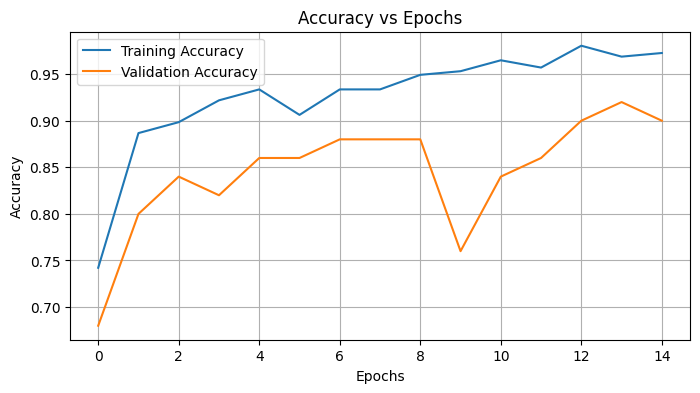

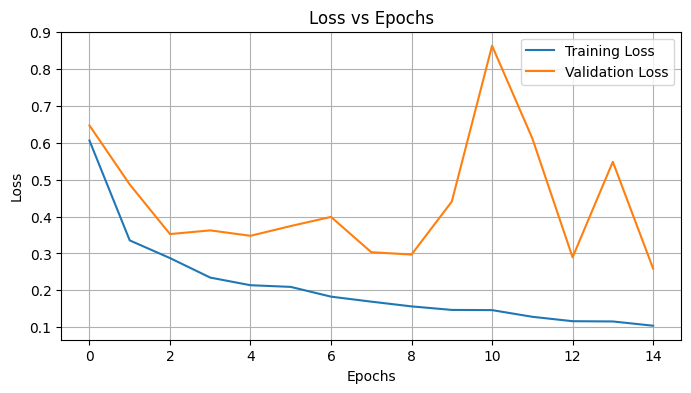

In [55]:
model=ANN()
loss_fn=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=0.001)
train(model, loss_fn, optimizer, train_loader, val_loader, train_data, val_data, epochs=15)


Epoch 1, Training Acc: 0.43, Validation Acc: 0.36, Training Loss: 1.09, Validation Loss: 1.11
Epoch 2, Training Acc: 0.43, Validation Acc: 0.36, Training Loss: 1.08, Validation Loss: 1.10
Epoch 3, Training Acc: 0.43, Validation Acc: 0.36, Training Loss: 1.07, Validation Loss: 1.06
Epoch 4, Training Acc: 0.43, Validation Acc: 0.36, Training Loss: 1.06, Validation Loss: 1.08
Epoch 5, Training Acc: 0.43, Validation Acc: 0.40, Training Loss: 1.06, Validation Loss: 1.09
Epoch 6, Training Acc: 0.45, Validation Acc: 0.54, Training Loss: 1.05, Validation Loss: 1.05
Epoch 7, Training Acc: 0.49, Validation Acc: 0.62, Training Loss: 1.04, Validation Loss: 1.04
Epoch 8, Training Acc: 0.52, Validation Acc: 0.72, Training Loss: 1.03, Validation Loss: 1.04
Epoch 9, Training Acc: 0.68, Validation Acc: 0.72, Training Loss: 1.01, Validation Loss: 1.04
Epoch 10, Training Acc: 0.71, Validation Acc: 0.76, Training Loss: 1.00, Validation Loss: 1.00
Epoch 11, Training Acc: 0.68, Validation Acc: 0.76, Trainin

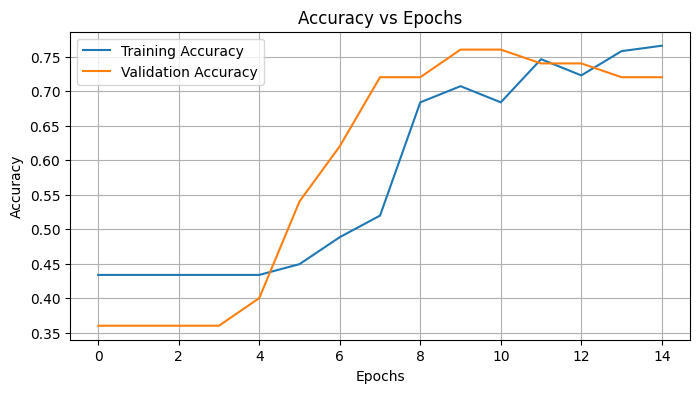

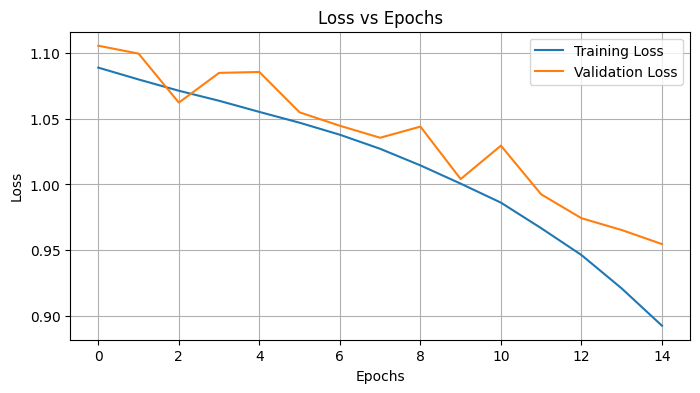

In [57]:
model=CNN()
loss_fn=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=0.001)
train(model, loss_fn, optimizer, train_loader, val_loader, train_data, val_data, epochs=15)

In [58]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size=360, seq_len=120, hidden_size=256, num_layers=2, num_classes=3):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM takes sequence of rows, each row has 120 * 3 = 360 values
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Fully connected layer
        self.fc = nn.Linear(seq_len * hidden_size, num_classes)

    def forward(self, img):
        # img: [B, 3, 120, 120]
        batch_size = img.size(0)

        # Flatten per row: [B, 120, 120*3] = [B, seq_len, input_size]
        img = img.permute(0, 2, 1, 3).contiguous()  # [B, 120, 3, 120]
        img = img.view(batch_size, 120, -1)         # [B, 120, 360]

        # Hidden states
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(img.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(img.device)

        # LSTM output
        out, _ = self.lstm(img, (h0, c0))           # [B, 120, 256]
        out = out.reshape(batch_size, -1)           # [B, 120*256]
        out = self.fc(out)                          # [B, 3]

        return out


Epoch 1, Training Acc: 0.76, Validation Acc: 0.58, Training Loss: 0.59, Validation Loss: 0.80
Epoch 2, Training Acc: 0.87, Validation Acc: 0.84, Training Loss: 0.43, Validation Loss: 0.43
Epoch 3, Training Acc: 0.94, Validation Acc: 0.86, Training Loss: 0.20, Validation Loss: 0.32
Epoch 4, Training Acc: 0.94, Validation Acc: 0.90, Training Loss: 0.17, Validation Loss: 0.29
Epoch 5, Training Acc: 0.98, Validation Acc: 0.88, Training Loss: 0.07, Validation Loss: 0.38
Epoch 6, Training Acc: 0.97, Validation Acc: 0.90, Training Loss: 0.11, Validation Loss: 0.22
Epoch 7, Training Acc: 0.97, Validation Acc: 0.92, Training Loss: 0.07, Validation Loss: 0.49
Epoch 8, Training Acc: 0.98, Validation Acc: 0.96, Training Loss: 0.07, Validation Loss: 0.24
Epoch 9, Training Acc: 0.97, Validation Acc: 0.90, Training Loss: 0.06, Validation Loss: 0.52
Epoch 10, Training Acc: 0.99, Validation Acc: 0.94, Training Loss: 0.04, Validation Loss: 0.26
Epoch 11, Training Acc: 0.98, Validation Acc: 0.92, Trainin

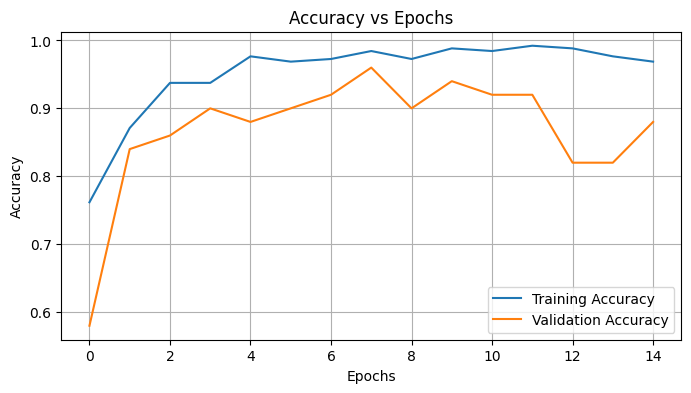

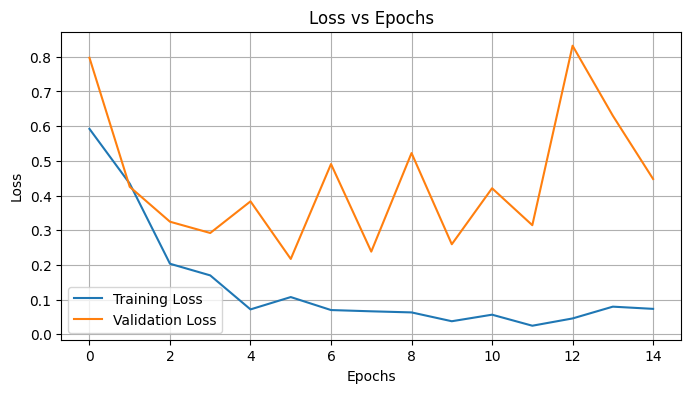

In [59]:
model = RNN()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train(model, loss_fn, optimizer, train_loader, val_loader, train_data, val_data, epochs=15)


In [63]:
def predict_img(img,model):
  x=img.unsqueeze(0)
  y=model(x)
  pred=torch.argmax(y,dim=1)
  return train_data.classes[pred]

Actual Label: Viral Pneumonia
Predicted Label: Viral Pneumonia


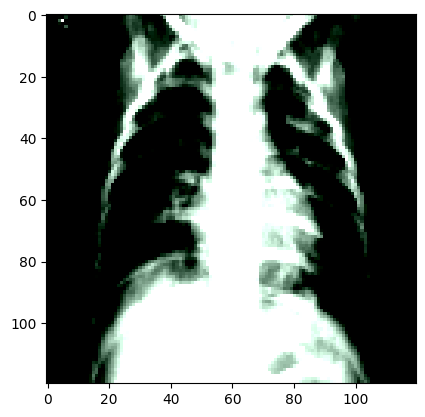

In [64]:
img, label= test_data[2]
plt.imshow(img.permute(1,2,0))
print("Actual Label:", train_data.classes[label])
print("Predicted Label:", predict_img(img,model))